<a href="https://colab.research.google.com/github/mmetee/python_2026/blob/main/mean_revers_backtest_3ys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install -U vectorbt
!pip install plotly

In [15]:
import yfinance as yf
import vectorbt as vbt
import pandas as pd
import matplotlib.pyplot as plt

# 1. กำหนดช่วงเวลา 3 ปี (ย้อนหลังจากปัจจุบัน)
symbols = ["EURUSD=X", "GBPUSD=X"]
start_date = "2023-01-01"
end_date = "2026-02-28"

# 2. ดึงข้อมูลราคา (แก้ไขเรื่อง Multi-index ให้จัดการง่ายขึ้น)
data = yf.download(symbols, start=start_date, end=end_date, multi_level_index=False)['Close']
data = data.dropna()

# 3. คำนวณ Bollinger Bands ด้วย Pandas (เพื่อเลี่ยง Error ของเวอร์ชัน vectorbt)
window = 20
std_dev = 2

sma = data.rolling(window=window).mean()
std = data.rolling(window=window).std()
upper_band = sma + (std_dev * std)
lower_band = sma - (std_dev * std)

# 4. สร้างสัญญาณเทรด (Logic: Mean Reversion)
# เข้าซื้อเมื่อราคาต่ำกว่าเส้นล่าง
entries = data < lower_band
# ปิดสถานะเมื่อราคากลับมาแตะเส้นกลาง (SMA)
exits = data > sma

# 5. รัน Backtest ด้วย VectorBT
# sl_stop=0.015 คือการตั้ง Stop Loss ไว้ที่ 1.5% เพื่อความปลอดภัย
pf = vbt.Portfolio.from_signals(
    data,
    entries,
    exits,
    fees=0.0001,
    init_cash=10000,
    sl_stop=0.015
)

# 6. แสดงผลลัพธ์สรุป
print("--- สรุปผลตอบแทนแยกตามคู่เงิน ---")
print(pf.total_return())
print("\n--- สถิติภาพรวม ---")
print(pf.stats())

# แสดงกราฟ
pf['EURUSD=X'].plot().show()
pf['GBPUSD=X'].plot().show()


/tmp/ipython-input-467/2836907995.py:12: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  2 of 2 completed
/usr/local/lib/python3.12/dist-packages/vectorbt/generic/stats_builder.py:396: UserWarning:

Metric 'sharpe_ratio' requires frequency to be set

/usr/local/lib/python3.12/dist-packages/vectorbt/generic/stats_builder.py:396: UserWarning:

Metric 'calmar_ratio' requires frequency to be set

/usr/local/lib/python3.12/dist-packages/vectorbt/generic/stats_builder.py:396: UserWarning:

Metric 'omega_ratio' requires frequency to be set

/usr/local/lib/python3.12/dist-packages/vectorbt/generic/stats_builder.py:396: UserWarning:

Metric 'sortino_ratio' requires frequency to be set

/tmp/ipython-input-467/2836907995.py:45: UserWarning:

Object has multiple columns. Aggregating using <function mean at 0x780467fcda80>. Pass column to select a single column/group.



--- สรุปผลตอบแทนแยกตามคู่เงิน ---
Ticker
EURUSD=X    0.069653
GBPUSD=X    0.064243
Name: total_return, dtype: float64

--- สถิติภาพรวม ---
Start                         2023-01-02 00:00:00
End                           2026-02-27 00:00:00
Period                                        820
Start Value                               10000.0
End Value                            10669.483493
Total Return [%]                         6.694835
Benchmark Return [%]                    10.760513
Max Gross Exposure [%]                      100.0
Total Fees Paid                         32.689345
Max Drawdown [%]                         3.227909
Max Drawdown Duration                       189.0
Total Trades                                 16.0
Total Closed Trades                          16.0
Total Open Trades                             0.0
Open Trade PnL                                0.0
Win Rate [%]                                 75.0
Best Trade [%]                           1.888949
Worst Trade

/tmp/ipython-input-467/972850374.py:3: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  2 of 2 completed


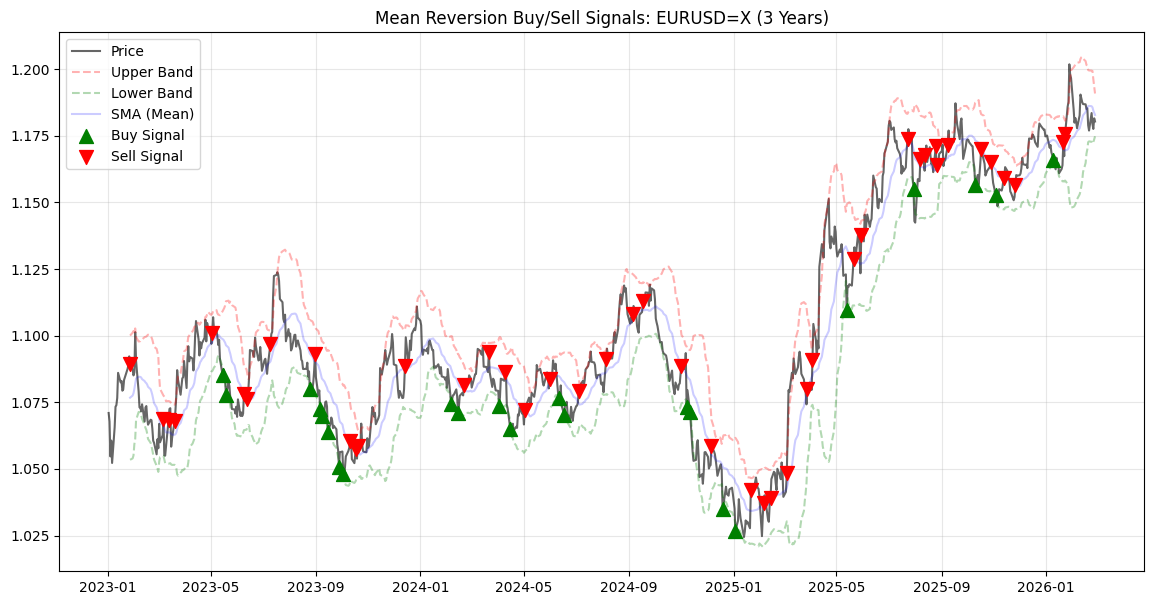

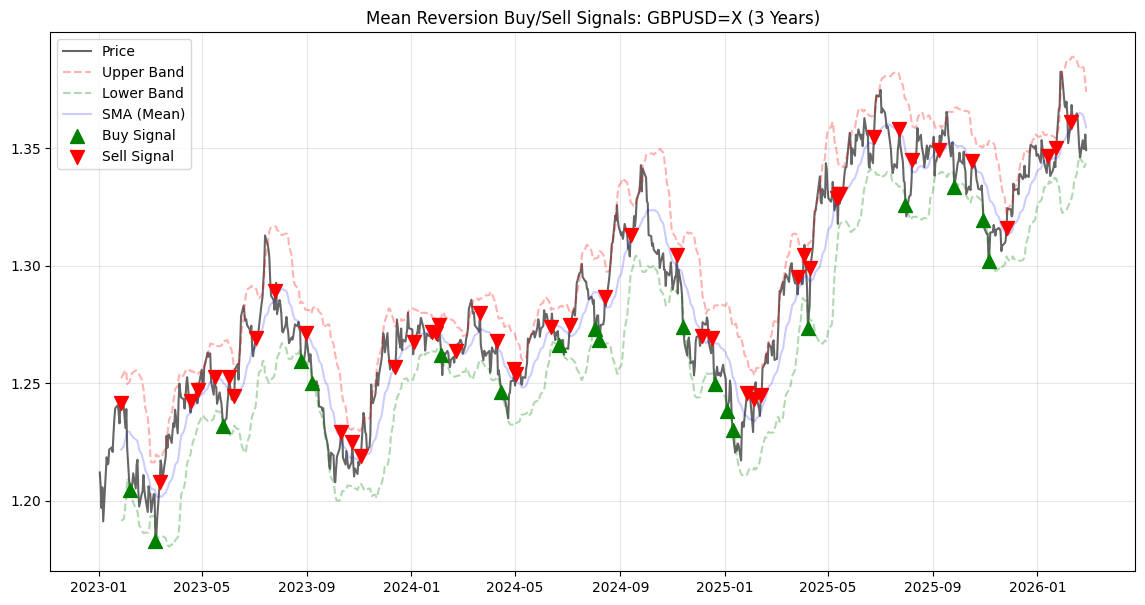

In [14]:


# 1. ดึงข้อมูลย้อนหลัง 3 ปี (2023 - ปัจจุบัน)
symbols = ["EURUSD=X", "GBPUSD=X"]
data = yf.download(symbols, start="2023-01-01", end="2026-02-28", multi_level_index=False)['Close']
data = data.dropna()

def plot_mean_reversion(symbol_name):
    df = data[[symbol_name]].copy()
    window = 20
    std_dev = 2

    # 2. คำนวณ Bollinger Bands
    df['SMA'] = df[symbol_name].rolling(window=window).mean()
    df['STD'] = df[symbol_name].rolling(window=window).std()
    df['Upper'] = df['SMA'] + (std_dev * df['STD'])
    df['Lower'] = df['SMA'] - (std_dev * df['STD'])

    # 3. สร้างสัญญาณซื้อขาย
    # ซื้อเมื่อราคาต่ำกว่าเส้นล่าง (Lower Band)
    df['Buy_Signal'] = (df[symbol_name] < df['Lower'])
    # ขายเมื่อราคาสูงกว่าเส้นกลาง (SMA)
    df['Sell_Signal'] = (df[symbol_name] > df['SMA'])

    # กรองเฉพาะจุดแรกที่เกิดสัญญาณ (เพื่อไม่ให้ลูกศรซ้อนกัน)
    df['Buy_Points'] = df[symbol_name][df['Buy_Signal'] & (df['Buy_Signal'].shift(1) == False)]
    df['Sell_Points'] = df[symbol_name][df['Sell_Signal'] & (df['Sell_Signal'].shift(1) == False)]

    # 4. พล็อตกราฟ
    plt.figure(figsize=(14, 7))
    plt.plot(df.index, df[symbol_name], label='Price', color='black', alpha=0.6)
    plt.plot(df.index, df['Upper'], label='Upper Band', color='red', linestyle='--', alpha=0.3)
    plt.plot(df.index, df['Lower'], label='Lower Band', color='green', linestyle='--', alpha=0.3)
    plt.plot(df.index, df['SMA'], label='SMA (Mean)', color='blue', alpha=0.2)

    # ใส่จุดซื้อ (ลูกศรขึ้นสีเขียว)
    plt.scatter(df.index, df['Buy_Points'], label='Buy Signal', marker='^', color='green', s=100, zorder=5)
    # ใส่จุดขาย (ลูกศรลงสีแดง)
    plt.scatter(df.index, df['Sell_Points'], label='Sell Signal', marker='v', color='red', s=100, zorder=5)

    plt.title(f'Mean Reversion Buy/Sell Signals: {symbol_name} (3 Years)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# รันกราฟทีละคู่เงิน
plot_mean_reversion("EURUSD=X")
plot_mean_reversion("GBPUSD=X")
